In [ ]:
import numpy as np
import pandas as pd

In [ ]:
comments = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
comments.head()

# 1 - positive comment
# -1 - negative comment
# 0 - neutral comment

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [ ]:
comments.shape
# so we have about 37000 comments in our dataset

(37249, 2)

In [ ]:
comments.sample()['clean_comment'].values

array(['wax and wane methinks '], dtype=object)

In [ ]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [ ]:
comments.isnull().sum()

,0
clean_comment,100
category,0


In [ ]:
comments[comments['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [ ]:
comments[comments['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,100


In [ ]:
# lets remove these 100 nan values form our 37000+ rows dataset
comments.dropna(inplace=True)

In [ ]:
comments.duplicated().sum()

np.int64(350)

In [ ]:
comments[comments.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [ ]:
comments.drop_duplicates(inplace=True)

In [ ]:
comments.duplicated().sum()

np.int64(0)

In [ ]:
# there could be cases that the new line in a comment is considered as a new row
comments[comments['clean_comment'].str.strip() == '']

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [ ]:
comments = comments[~(comments['clean_comment'].str.strip() == '')]

In [ ]:
# convert the clean_comment column into lowercase
comments['clean_comment'] = comments['clean_comment'].str.lower()

comments.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [ ]:
# we have to check if the strat or end of a comment has empty space. we need to remove that empty sppace
comments[comments['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [ ]:
# removing these leading and trailing whitespaces
comments['clean_comment'] = comments['clean_comment'].str.strip()

In [ ]:
# lets recheck if the transformation is done
comments[comments['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category


In [ ]:
# lets see if any comments have urls in them
url = r'/(https?:\/\/(?:www\.|(?!www))[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|www\.[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|https?:\/\/[a-zA-Z0-9]+\.[^\s]{2,}|[a-zA-Z0-9]+\.[^\s]{2,})/gi'

comments_with_url = comments[comments['clean_comment'].str.contains(url, regex=True)]

/tmp/ipython-input-2825141624.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  comments_with_url = comments[comments['clean_comment'].str.contains(url, regex=True)]


In [ ]:
comments_with_url.head()

# this shows that there are no url present in our data

,clean_comment,category


In [ ]:
# checking if any comments have a new line charachter \n
comment_with_newline = comments[comments['clean_comment'].str.contains('\n')]
comment_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [ ]:
# lets replace these \n with empty space

comments['clean_comment'] = comments['clean_comment'].str.replace('\n', ' ', regex=True)

In [ ]:
# recheck if the transformation is done

comment_with_newline = comments[comments['clean_comment'].str.contains('\n')]
comment_with_newline.head()

,clean_comment,category


We have done data cleaning and pre-processing


# EDA

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='category', ylabel='count'>

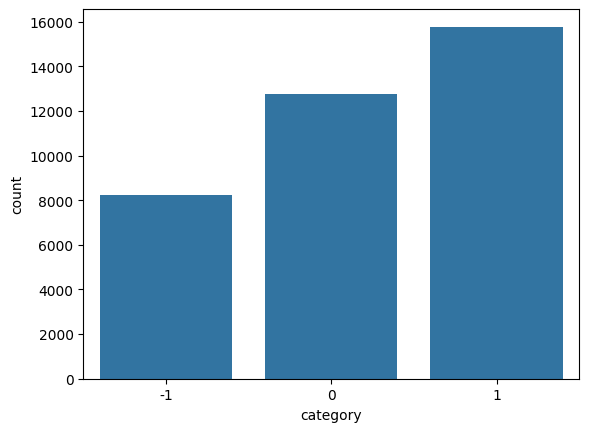

In [ ]:
# lets see the distribution of classes 1,0,-1
sns.countplot(data=comments, x ='category')

this tells us that the data is imbalanced as we have more positive comments and very few negative comments incomparison to that

In [ ]:
# lets see these distributions in terms of %
# frequency distribution of setiments

comments['category'].value_counts(normalize=True).mul(100).round(2)

# here comments['category'].value_counts() gives us occurrences of each unique value in the 'category' column
# normalize=True this argument divides each count by the total number of non-null values in the column. The resulting values are proportions that sum up to 1

,proportion
category,
1,42.86
0,34.71
-1,22.42


In [ ]:
# lets create a new column in the dataset which has wordcount of comment

comments['word_count'] = comments['clean_comment'].apply(lambda x: len(x.split()))

In [ ]:
comments.sample(10)

,clean_comment,category,word_count
5490,inch chest believe now,0,4
16361,one dimensional nothing has bas memory main st...,1,54
16535,congress form government gujarat major restruc...,-1,20
28765,sabse pehle twitter shutdown kro dono countries,0,7
32426,out the loop what all this about please,0,8
14465,big freakin deal,0,3
15921,trump funny guy you literally had laugh his gr...,-1,40
2131,looks like modi keeping defense for himself ed...,0,18
5965,baar congress sarkar,0,3
2101,average age cabinet ministers mos independent ...,-1,12


In [ ]:
comments['word_count'].describe()

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


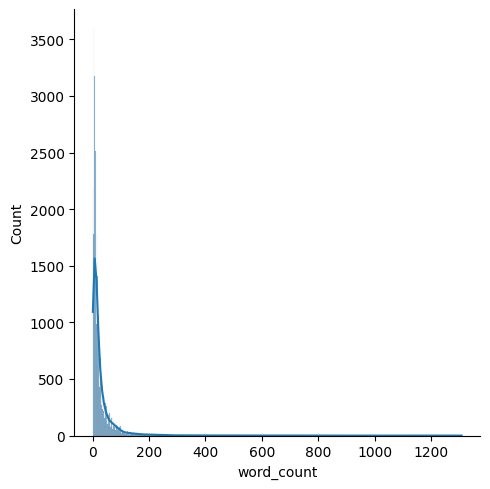

In [ ]:
sns.displot(comments['word_count'], kde=True)

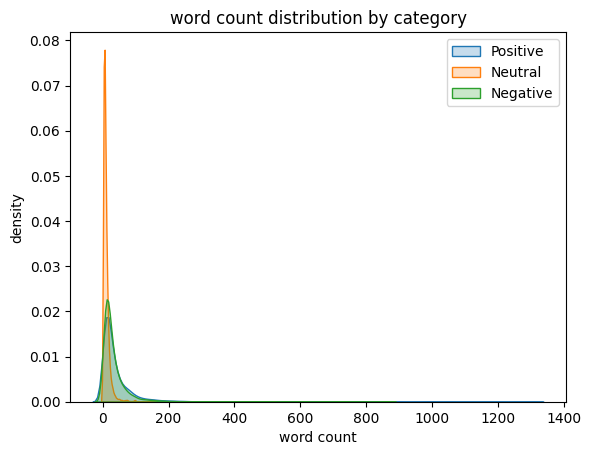

In [ ]:
# kde for category 1
sns.kdeplot(comments[comments['category']==1]['word_count'], label='Positive', fill=True)

# kde for category 0
sns.kdeplot(comments[comments['category']==0]['word_count'], label='Neutral', fill=True)

# kde for category -1
sns.kdeplot(comments[comments['category']==-1]['word_count'], label='Negative', fill=True)

plt.title('word count distribution by category')
plt.xlabel('word count')
plt.ylabel('density')

plt.legend()

plt.show()


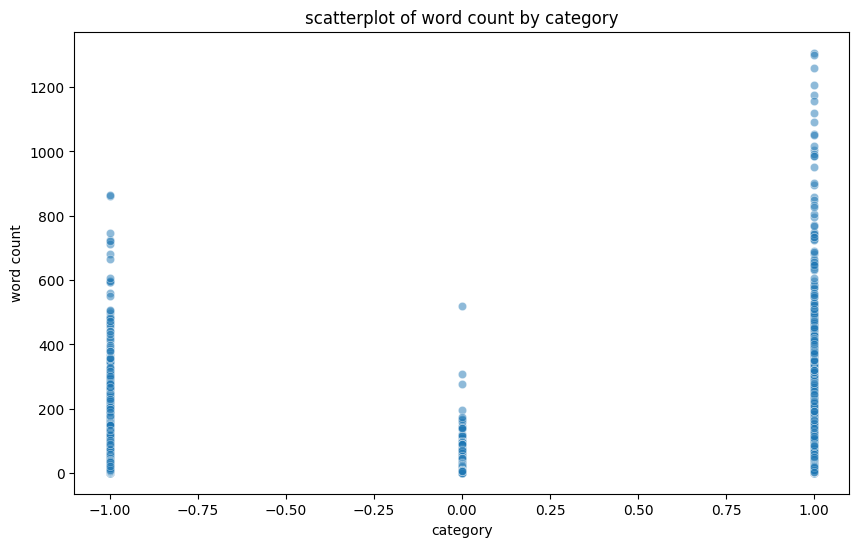

In [ ]:
# scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10,6))
sns.scatterplot(data=comments, x='category', y='word_count', alpha =0.5)
plt.title('scatterplot of word count by category')
plt.xlabel('category')
plt.ylabel('word count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

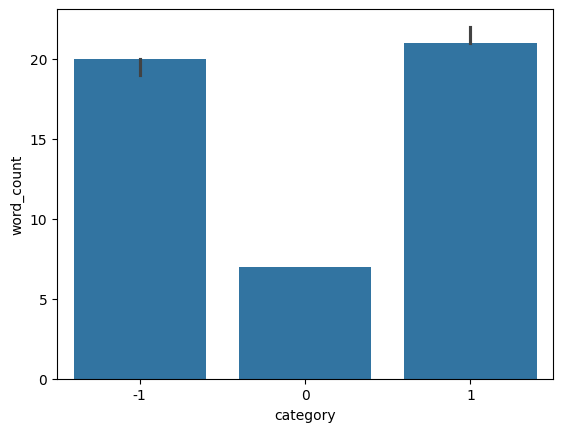

In [ ]:
# median word counts among sentiments

sns.barplot(data=comments, x='category', y='word_count', estimator='median')

In [ ]:
!pip install nltk

In [ ]:
from nltk.corpus import stopwords

import nltk
nltk.download('stopwords')
# stopwords are extremely common words, like "the," "a," and "is," that are often removed from text in natural language processing (NLP) tasks because they lack semantic meaning and don't add significant value to analysis

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# define the list of stopwords
stop_words = set(stopwords.words('english'))

# create a new column 'num_stop_words' by counting the number of stop words in each comment
comments['num_stop_words'] = comments['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [ ]:
comments.sample(10)

,clean_comment,category,word_count,num_stop_words
15206,are tired winning yet,1,4,1
638,totaltv aap bjp abp news,0,5,0
3600,the prime minister india for those wondering,0,7,3
6540,the entire police department needs rally again...,0,26,12
33363,furious head scratching are chowkidars also su...,0,8,1
7610,“never argue with idiot they will only bring y...,-1,18,10
27147,here another one refuting lgbtq attacks her cu...,-1,29,8
9891,standard scoring gronk @ jets gates @ texans,0,8,0
6779,which way north,0,3,1
5888,din aur fir gayi 2017 tak,0,6,0


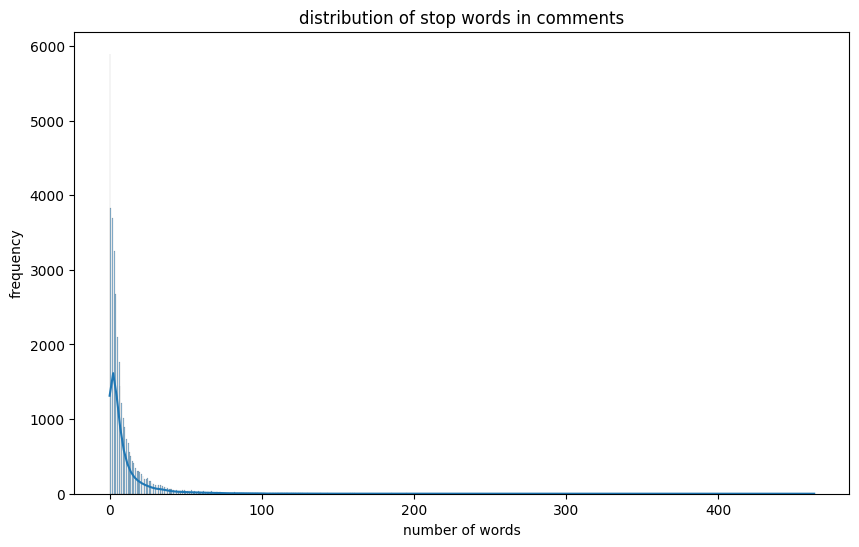

In [ ]:
# create a plot for the stopwords column

plt.figure(figsize=(10,6))
sns.histplot(comments['num_stop_words'], kde=True)
plt.title('distribution of stop words in comments')
plt.xlabel('number of words')
plt.ylabel('frequency')
plt.show()

the plot is heavily right-skewed. most comments have very few stopwords. and a long tail of longer comments that naturally contain many stopwords

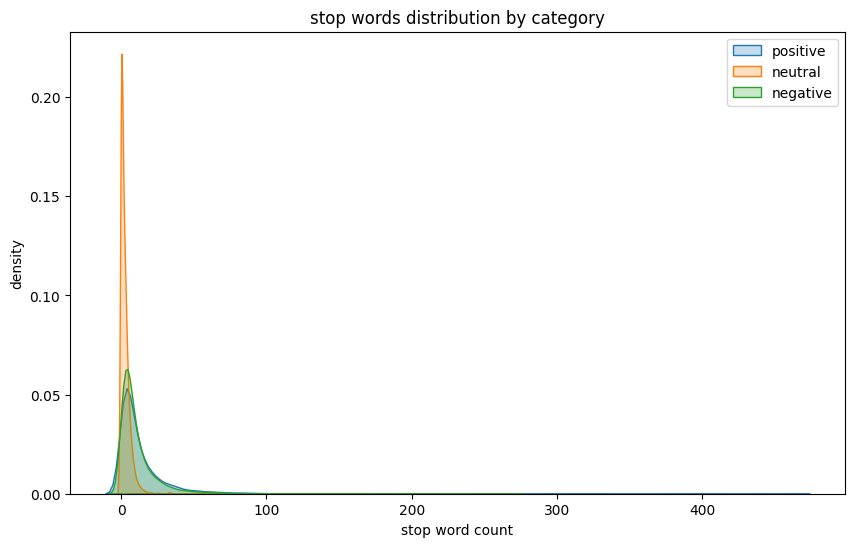

In [ ]:
plt.figure(figsize=(10,6))

# plot for category 1
sns.kdeplot(comments[comments['category']==1]['num_stop_words'], label = 'positive', fill=True)

# plot for category 0
sns.kdeplot(comments[comments['category']==0]['num_stop_words'], label = 'neutral', fill=True)

# plot for category -1
sns.kdeplot(comments[comments['category']==-1]['num_stop_words'], label = 'negative', fill=True)

plt.title('stop words distribution by category')
plt.xlabel('stop word count')
plt.ylabel('density')

plt.legend()

/tmp/ipython-input-3340713791.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_words', palette='viridis')


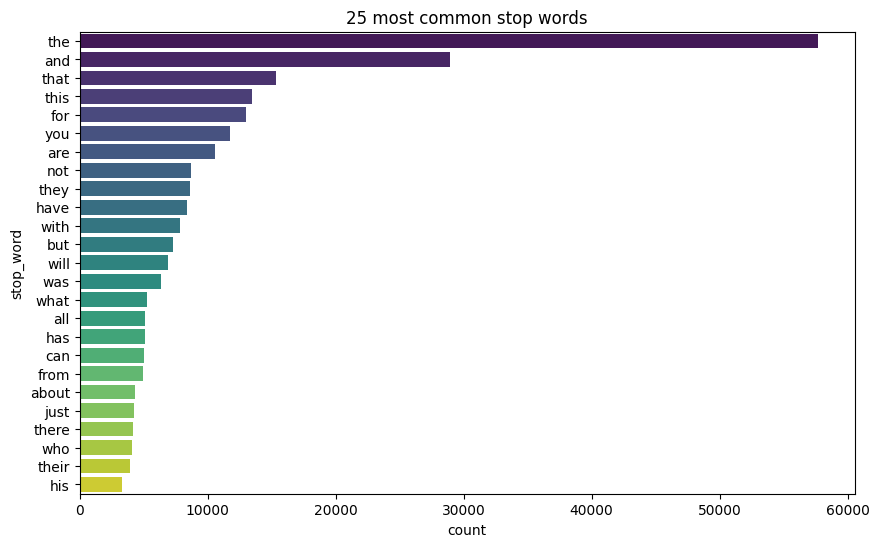

In [ ]:
# lets see what are the most used stopwords in this data

# create a frequency distb of words in the clean_comment col
from collections import Counter

# extract all stop words from the comments
all_stop_words = [word for comment in comments['clean_comment'] for word in comment.split() if word in stop_words]

# count the most common stop words to a df for plotting it
most_common_stop_words = Counter(all_stop_words).most_common(25)
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_words','count'])

# barplot for the 25 most common stop words
plt.figure(figsize=(10,6))
sns.barplot(data=top_25_df, x='count', y='stop_words', palette='viridis')
plt.title('25 most common stop words')
plt.xlabel('count')
plt.ylabel('stop_word')
plt.show()

In [ ]:
# lets count number of charachters in the comments
comments['num_chars'] = comments['clean_comment'].apply(len)
comments.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [ ]:
comments['num_chars'].describe()

,num_chars
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


In [ ]:
# now lets see how many special charachters we have in the comments
from collections import Counter

# combine all comments into one large string with a space between each comment
all_text = ' '.join(comments['clean_comment'])

# count the frequency of each charachter
char_freq = Counter(all_text)

# convert the charachter freq into a df for better display
char_freq_df = pd.DataFrame(char_freq.items(),columns=['charachter','frequency']).sort_values(by='frequency', ascending=True)


In [ ]:
char_freq_df.head(10)

,charachter,frequency
551,∀,1
550,￼,1
549,ಳ,1
548,ಗ,1
547,ಕ,1
545,¿,1
544,ṭ,1
543,î,1
541,õ,1
539,ɔ,1


In [ ]:
# create a new column to count punctuation characters in each comment

comments['num_puncuation_chars'] = comments['clean_comment'].apply (
    lambda x: sum(1 for char in x if char in ".,!?;:'\"()[]{}-")
)
comments.sample(7)

,clean_comment,category,word_count,num_stop_words,num_chars,num_puncuation_chars
7082,crush jat violence don’ get coerced centre har...,0,9,0,54,0
14777,subramanian swamy gst like satellite placed or...,1,22,9,141,0
23801,that sginstababes patreon shade deekosh kinda ...,0,10,3,67,0
4279,its time when people should unite force agains...,-1,32,14,176,0
18124,tol receive invite modi last time and sanjay l...,1,21,3,120,0
11791,donald used the rallies help people with long ...,1,34,10,204,0
18484,the problem with this whole issue that there n...,1,118,48,672,0


/tmp/ipython-input-3274807187.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


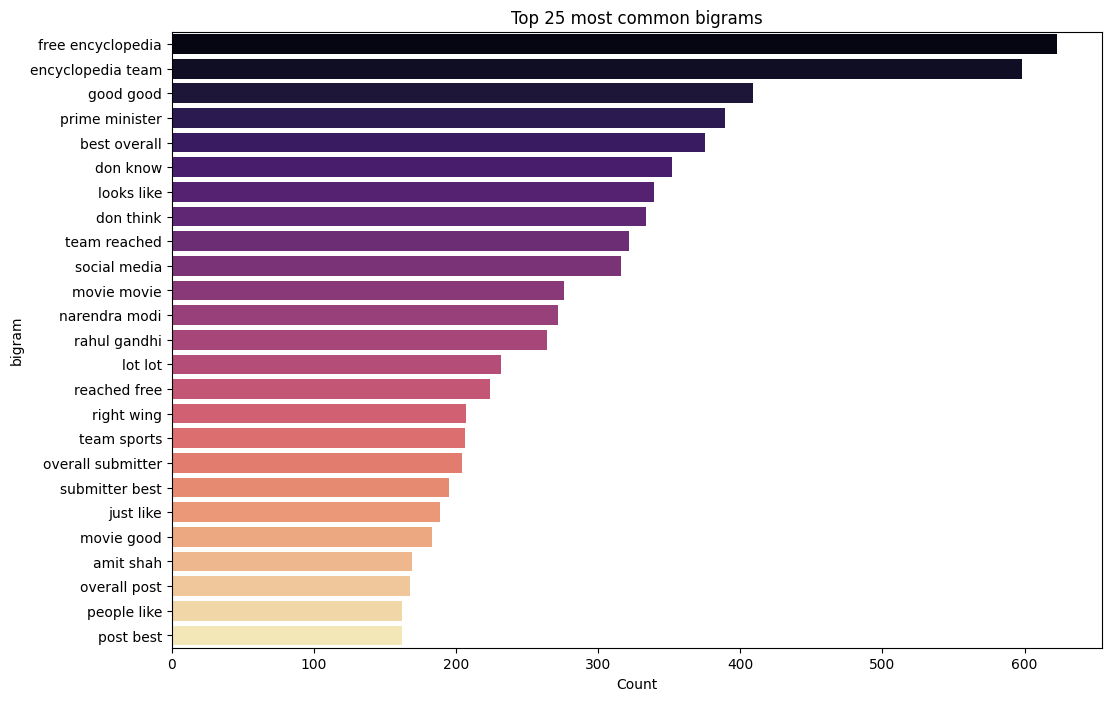

In [ ]:
# let us see the top n-grams distribution

from sklearn.feature_extraction.text import CountVectorizer

# creating a func to extract the top 25 bigrams
def top_ngrams(corpus, n=None):
  vec = CountVectorizer(ngram_range=(2,2), stop_words='english').fit(corpus)   # extracts bigrams and removes stopwords # .fit(corpus) learns the vocabulary of all bigrams that appear in corpus
  bag_of_words = vec.transform(corpus)    # Transforms the text into a sparse document-term matrix, rows= documents in corpus, cols = bigrams, values = count of each bigram in each document
  sum_words =  bag_of_words.sum(axis=0)   # total count of each bigram in the entire corpus
  words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
  return words_freq[:n]

# get the top 25 bigrams
top_25_bigrams = top_ngrams(comments['clean_comment'], 25)

# convert bigrams into df
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# countplot
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 most common bigrams')
plt.xlabel('Count')
plt.show()


/tmp/ipython-input-1870989922.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


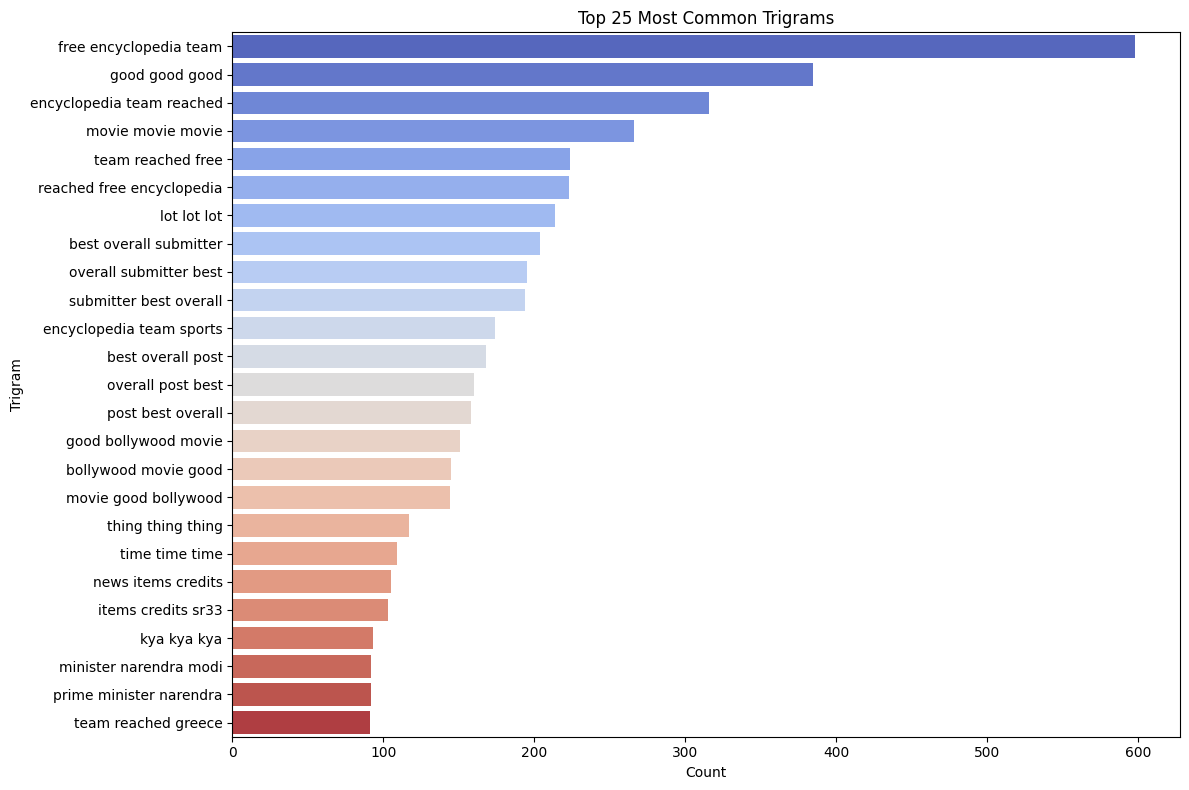

In [ ]:
# Create a function to extract the top N trigrams
from sklearn.feature_extraction.text import CountVectorizer

def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Collect trigram + frequency pairs
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    # Sort them by frequency (highest first)
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(comments['clean_comment'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams,
                                  columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()



In [ ]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only English letters, digits, whitespace, and common punctuation
import re

comments['clean_comment'] = comments['clean_comment'].apply(
    lambda x: re.sub(r"[^A-Za-z0-9\s!?,.']", '', str(x))
)


In [ ]:
# Join all comments into one long string
all_text = ' '.join(comments['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = (
    pd.DataFrame(char_frequency.items(), columns=['character', 'frequency'])
      .sort_values(by='frequency', ascending=False)
)

char_frequency_df


,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [ ]:
comments.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_puncuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [ ]:
from nltk.corpus import stopwords

# Define stop words but keep some important ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
comments['clean_comment'] = comments['clean_comment'].apply(
    lambda x: ' '.join(
        word for word in str(x).split() if word.lower() not in stop_words
    )
)


In [ ]:
comments.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_puncuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk

# Download WordNet data (run once)
nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment' column
comments['clean_comment'] = comments['clean_comment'].apply(
    lambda x: ' '.join(lemmatizer.lemmatize(word) for word in str(x).split())
)

comments.head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_puncuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


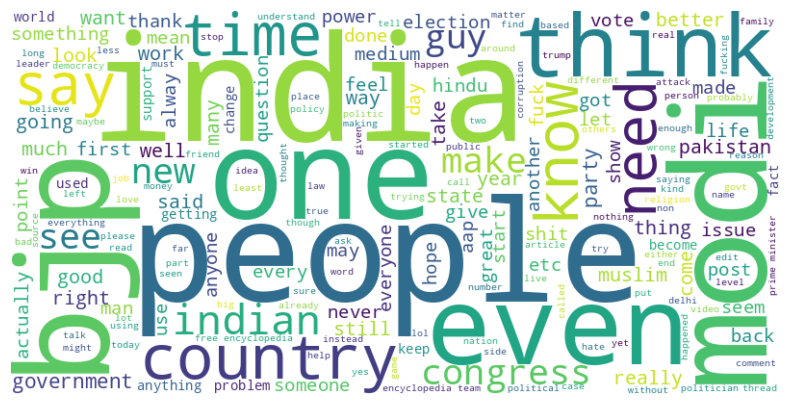

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    # text is expected to be a sequence/Series of strings (e.g., df['clean_comment'])
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(' '.join(text))   # join all comments into one big string

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

# Call the function on your cleaned comments
plot_word_cloud(comments['clean_comment'])


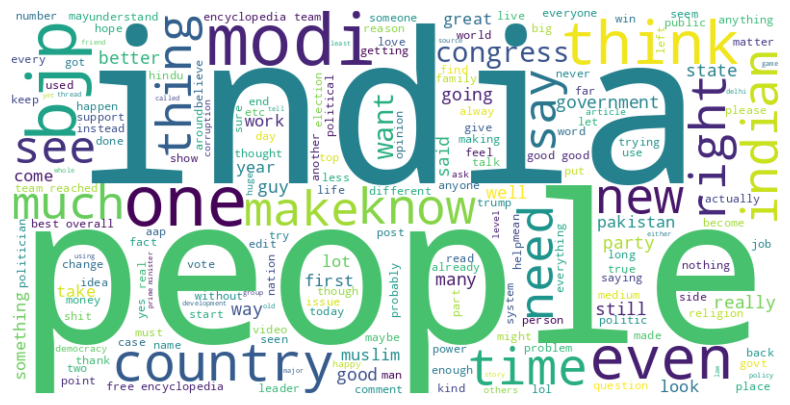

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(' '.join(text))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

# Word cloud only for rows where category == 1
plot_word_cloud(comments[comments['category'] == 1]['clean_comment'])


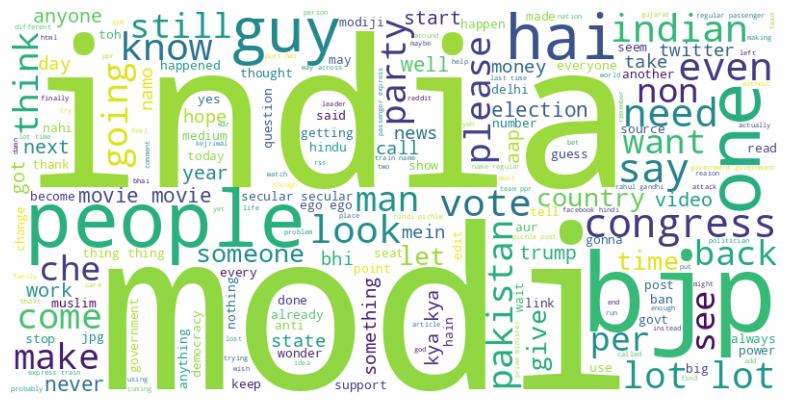

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(' '.join(text))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

# Word cloud only for rows where category == 1
plot_word_cloud(comments[comments['category'] == 0]['clean_comment'])


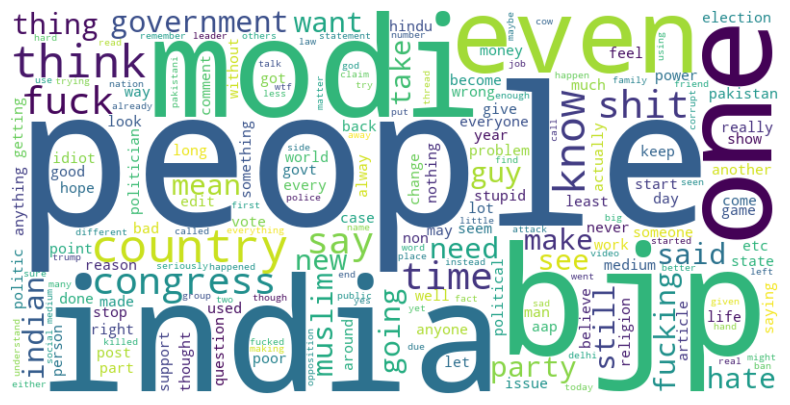

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(' '.join(text))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

# Word cloud only for rows where category == 1
plot_word_cloud(comments[comments['category'] == -1]['clean_comment'])


In [ ]:
def plot_top_n_words(comments, n=20):
    """Plot the top n most frequent words in the dataset."""

    # Flatten all words in the 'clean_comment' column
    words = ' '.join(comments['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)


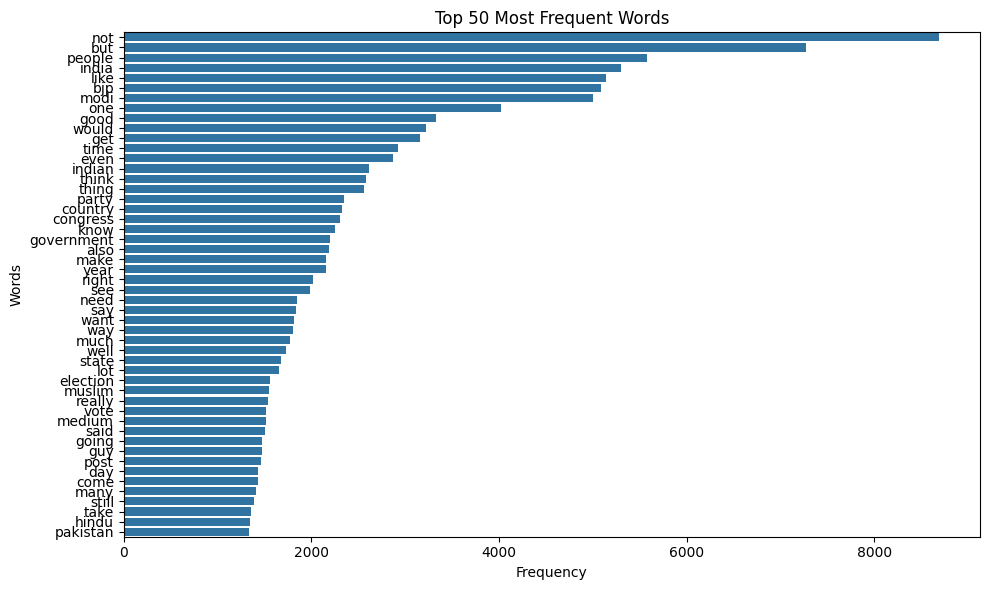

In [ ]:
plot_top_n_words(comments, n=50)

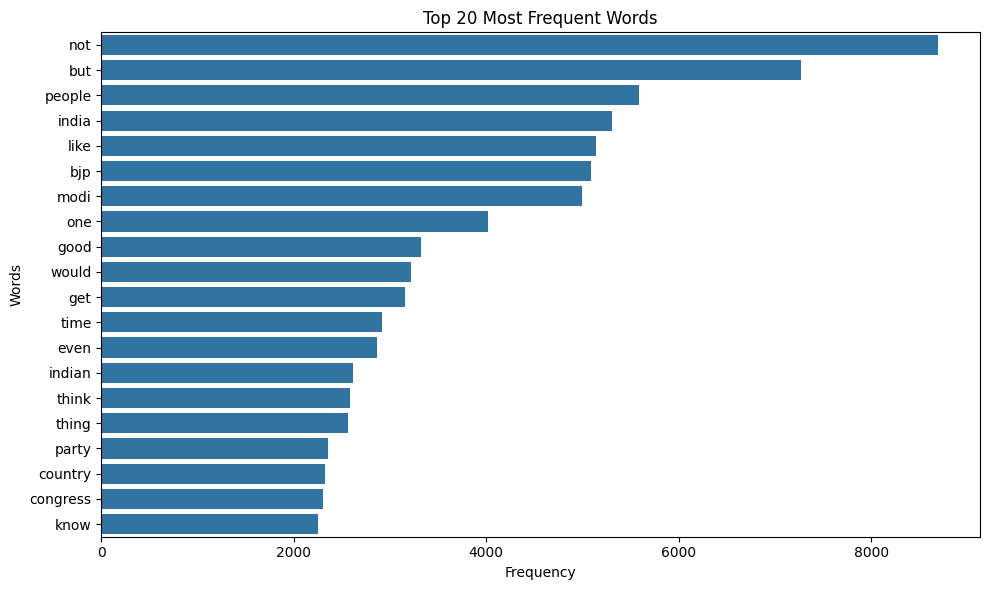

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_n_words(comments, n=20):
    words = ' '.join(comments['clean_comment']).split()
    counter = Counter(words)
    most_common_words = counter.most_common(n)
    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.tight_layout()
    plt.show()

plot_top_n_words(comments, 20)


In [ ]:
def plot_top_n_words_by_category(comments, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in comments.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  # Initialize counts for each sentiment category

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1

    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show()


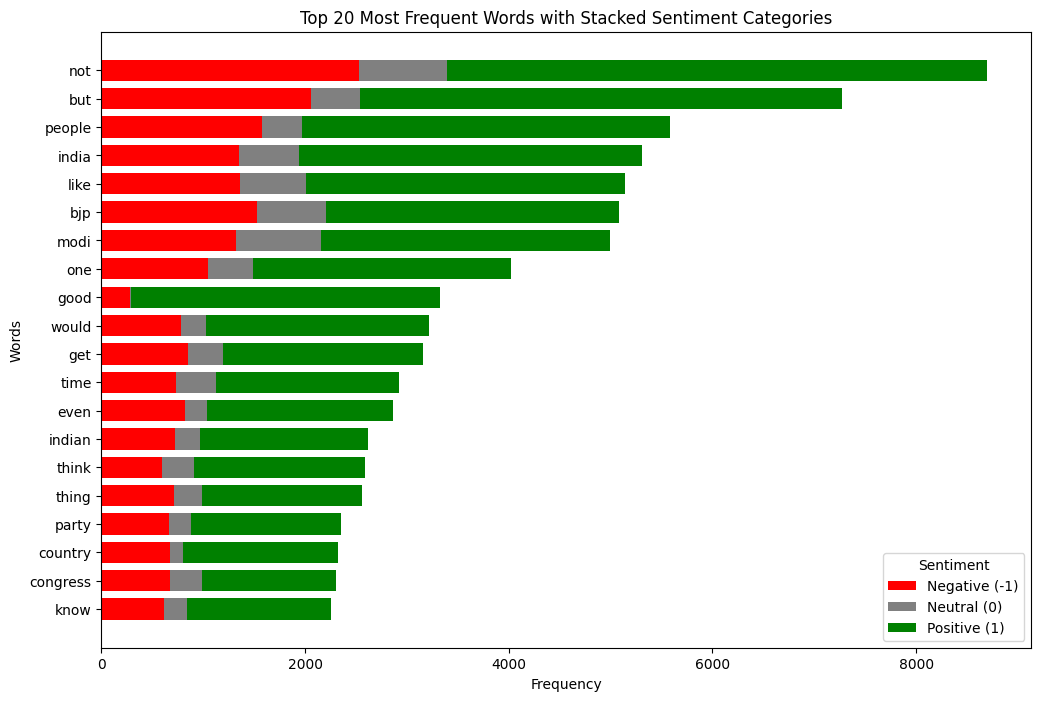

In [ ]:
plot_top_n_words_by_category(comments, n=20)